  # II. DESCRIPTIVE ANALYSIS

## 1. Introduction

The objective of this analysis is to identify meaningful patterns, relationships,
and variations within the hospitalized heart-failure patient population.

The analysis focuses on patient characteristics, clinical severity, cardiac
function, laboratory measurements, complications, medications, and
hospitalization outcomes. Rather than only presenting summary statistics,
specific analytical questions will be used to investigate important patterns
within the data.

Each question will be supported by an appropriate analysis and visualization,
followed by an interpretation of the findings. The findings will also help
identify areas that can be explored further through prescriptive and predictive
analysis.

### 2. Import Libraries

The analysis uses Pandas and NumPy for data manipulation and numerical
analysis, while Matplotlib and Seaborn are used to create clear and
informative visualizations.

In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Visualization style
sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


### 3. Load Master Patient Dataset

The cleaned patient-level datasets were combined during the data preparation
stage to create the master patient table. This table contains one row per
patient and serves as the common analytical dataset for the descriptive,
prescriptive, and predictive stages.

The master table is loaded from the cleaned-data folder so that this notebook
uses the same validated analytical population without repeating the earlier
cleaning and merging process.

In [ ]:
# Use the team's original data folder when it is available.
TEAM_DATA_PATH = Path(
    r"C:\Users\arjai\Documents\Shraddha Job Search\Data Science\Python\Hackathon Sept 2026\Python_Hackathon_Sep_2026"
)

# Jupyter normally starts in the notebook folder; also check its parent.
# In either folder, the cleaning notebook should have created cleaned_data/patient_master.csv.
candidate_folders = [TEAM_DATA_PATH, Path.cwd(), Path.cwd().parent]
DATA_PATH = next(
    (folder for folder in candidate_folders
     if (folder / "cleaned_data" / "patient_master.csv").is_file()),
    None,
)
if DATA_PATH is None:
    raise FileNotFoundError(
        "Cannot find cleaned_data/patient_master.csv. Run the team's cleaning "
        "notebook first, or open this notebook from the project folder."
    )

CLEANED_PATH = DATA_PATH / "cleaned_data"
MASTER_PATH = CLEANED_PATH / "patient_master.csv"
patient_master = pd.read_csv(MASTER_PATH)

print("Master patient dataset loaded from:", MASTER_PATH)
print(f"Rows: {patient_master.shape[0]:,}")
print(f"Columns: {patient_master.shape[1]:,}")


In [3]:
# Create the dataframe used for descriptive analysis

df = patient_master.copy()

print("Descriptive analysis dataframe created.")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")

Descriptive analysis dataframe created.
Rows: 2,008
Columns: 198


### 4. Initial Dataset Validation

Before beginning the descriptive questions, the master dataset is checked
to confirm that the expected patient-level structure has been preserved.

The checks focus on the dataset size, patient identifier uniqueness,
duplicate records, data types, and missing values. This provides confidence
that the analysis is being performed on the intended analytical population
and helps identify variables that may require consideration when answering
individual questions.

In [4]:
# Dataset structure

print("Dataset Shape:", df.shape)

print("\nNumber of Patients:", df["inpatient_number"].nunique())

print("Duplicate Patient IDs:",
      df["inpatient_number"].duplicated().sum())

print("Duplicate Rows:",
      df.duplicated().sum())

Dataset Shape: (2008, 198)

Number of Patients: 2008
Duplicate Patient IDs: 0
Duplicate Rows: 0


In [5]:
# Data type summary

print("Data Type Summary:")
display(df.dtypes.value_counts())

Data Type Summary:


float64    149
int64       30
object      14
bool         5
Name: count, dtype: int64

In [6]:
# Missing-value overview

missing_summary = (
    df.isna()
      .sum()
      .sort_values(ascending=False)
)

missing_summary = missing_summary[missing_summary > 0]

print("Columns with missing values:", len(missing_summary))

display(missing_summary.head(30))

Columns with missing values: 123


respiratory_support                             1966
time_of_death_days_from_admission               1964
homocysteine                                    1862
apolipoprotein_a                                1832
lipoprotein                                     1832
apolipoprotein_b                                1832
tricuspid_valve_return_pressure                 1826
erythrocyte_sedimentation_rate                  1701
ea                                              1615
myoglobin                                       1610
serum_magnesium                                 1601
inorganic_phosphorus                            1601
mitral_valve_ams                                1458
glutamic_oxaliplatin                            1416
lvef                                            1373
tricuspid_valve_return_velocity                 1218
time_to_emergency_department_within_6_months    1111
readmission_time_days_from_admission            1107
high_sensitivity_protein                      

## Question 1 — How many patients are in each NYHA class and Killip grade?

**Why these fields?** NYHA class describes limits on physical activity from heart failure symptoms. Killip grade records clinical signs of cardiac severity. Together, their *separate* distributions describe this patient group at admission. They measure different things, so matching class numbers would not mean the two assessments agree.

**How we answer it:** Check that both fields contain the grades documented in the team's cleaned table, count patients in each grade, and calculate each grade's share of all patients. Show missing records separately so the percentages have a clear denominator. Then plot the two distributions. A later question can examine how the two grades overlap within the same patients.

The [American Heart Association explains NYHA classes](https://www.heart.org/en/health-topics/heart-failure/what-is-heart-failure/classes-of-heart-failure); the dataset's data dictionary defines the recorded Killip grades.


In [7]:
# Step 1: Identify the two cleaned columns and the grades we expect in each.
severity_fields = {
    "NYHA class": ("nyha_cardiac_function_classification", [2, 3, 4]),
    "Killip grade": ("killip_grade", [1, 2, 3, 4]),
}

# Check the column names before calculating anything. A missing column means
# the wrong version of patient_master.csv may have been loaded.
missing_columns = [column for column, _ in severity_fields.values() if column not in df.columns]
if missing_columns:
    raise KeyError(f"Severity columns missing from patient_master.csv: {missing_columns}")

severity_tables = {}
for name, (column, possible_grades) in severity_fields.items():
    # Convert to numbers, but stop if a non-empty value is not a documented grade.
    numeric = pd.to_numeric(df[column], errors="coerce")
    invalid = df[column].notna() & (numeric.isna() | ~numeric.isin(possible_grades))
    if invalid.any():
        raise ValueError(f"{name} has {int(invalid.sum())} unrecognized grade(s); review the source.")

    # Include grades with zero patients to make the distributions easy to compare.
    counts = numeric.value_counts().reindex(possible_grades, fill_value=0).astype(int)
    severity_tables[name] = pd.DataFrame({
        "Grade": possible_grades,
        "Patients": counts.to_numpy(),
        "Percent of all patients": (counts.to_numpy() / len(df) * 100).round(1),
    })

    # The denominator is the full master table; show missing grades explicitly.
    print(f"\n{name}: {int(numeric.notna().sum()):,} recorded; {int(numeric.isna().sum()):,} missing")
    display(severity_tables[name])



NYHA class: 2,008 recorded; 0 missing


,Grade,Patients,Percent of all patients
0,2,353,17.6
1,3,1039,51.7
2,4,616,30.7



Killip grade: 2,008 recorded; 0 missing


,Grade,Patients,Percent of all patients
0,1,527,26.2
1,2,1029,51.2
2,3,392,19.5
3,4,60,3.0


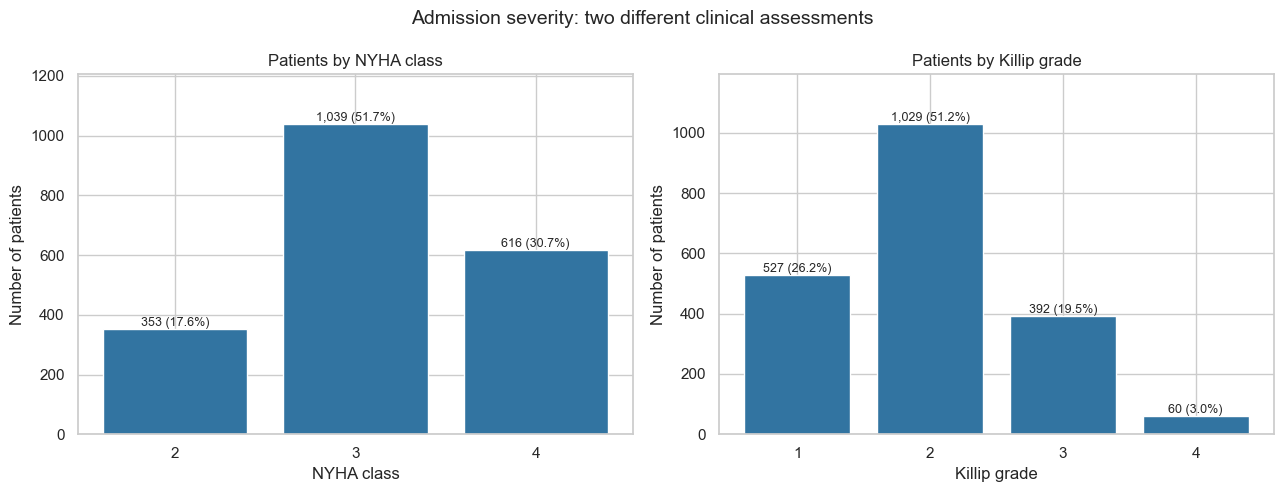

Most common NYHA class: 3 — 1,039 patients (51.7% of all patients).
Most common Killip grade: 2 — 1,029 patients (51.2% of all patients).


In [8]:
# Step 2: Show one bar chart per clinical assessment, with both counts and percentages.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (name, summary) in zip(axes, severity_tables.items()):
    bars = ax.bar(summary["Grade"].astype(str), summary["Patients"], color="#3274a1")
    ax.set(title=f"Patients by {name}", xlabel=name, ylabel="Number of patients")
    ax.set_ylim(0, max(1, summary["Patients"].max()) * 1.16)
    for bar, count, percent in zip(bars, summary["Patients"], summary["Percent of all patients"]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                f"{count:,} ({percent:.1f}%)", ha="center", va="bottom", fontsize=9)

fig.suptitle("Admission severity: two different clinical assessments", fontsize=14)
plt.tight_layout()
plt.show()

# State a finding using the real counts after the dataset has been loaded.
for name, summary in severity_tables.items():
    largest = summary.loc[summary["Patients"].idxmax()]
    print(f"Most common {name}: {int(largest['Grade'])} — "
          f"{int(largest['Patients']):,} patients ({largest['Percent of all patients']:.1f}% of all patients).")


### What Question 1 tells us

The tables and charts establish how common each recorded severity grade is in the full patient group. Use the displayed percentages and missing counts when describing the result. A large count for one grade tells us that grade was common *in this dataset*; it does not explain what caused the patient's condition.


## Question 2 — How do NYHA classes and Killip grades overlap in the same patients?

**Why this question?** Question 1 counts each grade separately. A table of patients who have *both* recorded scores shows which combinations occurred together, including whether patients within one NYHA class received several different Killip grades. This helps the team decide what comparisons to explore later.

**How we answer it:** Keep only patients with both recorded grades. Cross-tabulate their NYHA class and Killip grade, then divide each NYHA row by its own total. A heatmap displays the counts and within-class percentages. We also report how many patients were left out for missing grades.

**Interpretation limit:** NYHA and Killip assess different aspects of illness. Their numerical grade labels do not mean the same thing, so a diagonal on the chart is **not** an agreement rate. Formal correlation and outcome comparisons belong in the separate prescriptive notebook.


In [9]:
# Step 1: Use the same patient-level table as Question 1.
nyha_column = "nyha_cardiac_function_classification"
killip_column = "killip_grade"
severity_pairs = df[[nyha_column, killip_column]].dropna().copy()

# Count every observed NYHA/Killip combination; keep the expected grade order.
pair_counts = pd.crosstab(
    severity_pairs[nyha_column].astype(int),
    severity_pairs[killip_column].astype(int),
).reindex(index=[2, 3, 4], columns=[1, 2, 3, 4], fill_value=0)
pair_counts.index.name = "NYHA class"
pair_counts.columns.name = "Killip grade"

# Each percentage is within one NYHA class (each nonempty row sums to 100%).
row_totals = pair_counts.sum(axis=1)
pair_percent = pair_counts.div(row_totals.replace(0, np.nan), axis=0).mul(100).round(1)

print(f"Patients with both grades: {len(severity_pairs):,} of {len(df):,}")
print(f"Patients missing one or both grades: {len(df) - len(severity_pairs):,}")
print("\nNumber of patients in each combination:")
display(pair_counts)
print("Percent within each NYHA class (rows):")
display(pair_percent)


Patients with both grades: 2,008 of 2,008
Patients missing one or both grades: 0

Number of patients in each combination:


Killip grade,1,2,3,4
NYHA class,,,,
2,136,151,66,0
3,304,543,190,2
4,87,335,136,58


Percent within each NYHA class (rows):


Killip grade,1,2,3,4
NYHA class,,,,
2,38.5,42.8,18.7,0.0
3,29.3,52.3,18.3,0.2
4,14.1,54.4,22.1,9.4


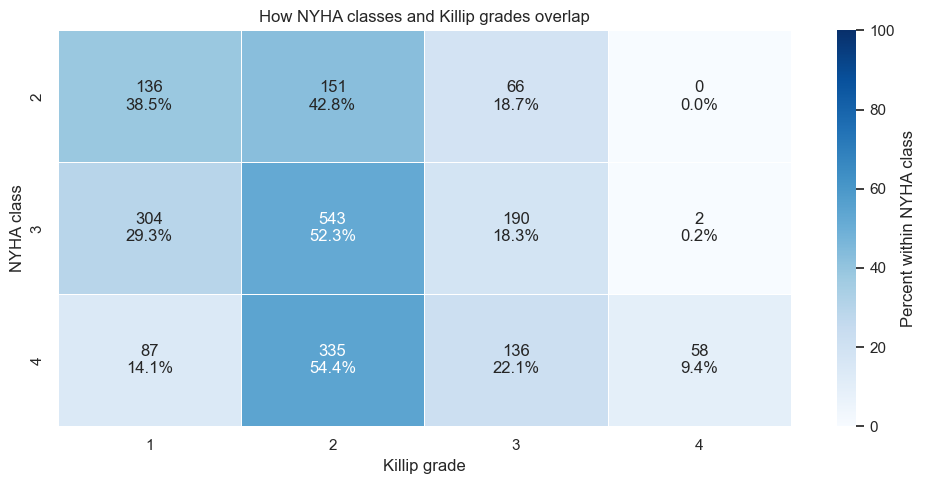

Most frequent combination: NYHA 3 and Killip 2 (543 patients, 27.0% of patients with both grades).


In [10]:
# Step 2: Label each heatmap cell with both the patient count and the row percentage.
labels = np.array([
    [f"{pair_counts.loc[nyha, killip]:,}\n{pair_percent.loc[nyha, killip]:.1f}%"
     if row_totals.loc[nyha] else "No patients"
     for killip in pair_counts.columns]
    for nyha in pair_counts.index
])

plt.figure(figsize=(10, 5))
sns.heatmap(
    pair_percent.fillna(0), annot=labels, fmt="", cmap="Blues", vmin=0, vmax=100,
    cbar_kws={"label": "Percent within NYHA class"}, linewidths=0.5,
)
plt.title("How NYHA classes and Killip grades overlap")
plt.xlabel("Killip grade")
plt.ylabel("NYHA class")
plt.tight_layout()
plt.show()

# Give the reader a factual result without claiming that matching numbers mean agreement.
largest_pair = pair_counts.stack().idxmax()
largest_count = int(pair_counts.loc[largest_pair])
print(f"Most frequent combination: NYHA {largest_pair[0]} and Killip {largest_pair[1]} "
      f"({largest_count:,} patients, {largest_count / len(severity_pairs):.1%} of patients with both grades).")


### What Question 2 tells us

Read *across a row* to see how Killip grades are distributed among patients in one NYHA class. The percentage denominator changes from row to row and is printed in the table above. The chart describes overlap in this patient group; it cannot tell us that one score causes the other or that the two assessments measure the same condition.


<p style="font-family: Cambria; font-size: 18px;"><b>Q3. What does cardiac function (LVEF) and type of heart failure look like across the cohort?</b></p>

**Why:** LVEF and HF type describe the structural/functional picture of the heart — the next layer after admission severity.

**What:** `lvef`, `type_of_heart_failure`.

**How:** Distribution + explicit missingness callout, since LVEF is only recorded for a minority of patients.

**Counter-Argument:** With ~68% missing, is this worth showing? Yes — *how much* and *whether it's random* is itself a finding, not a reason to skip the column.

**What We Expect:** A left-skewed distribution (more reduced-EF patients, since this is a hospitalized HF cohort).

**Evidence:** LVEF recorded for only 635 of 2,008 patients (31.6%; 68.4% missing). Among those recorded: mean 50.7%, median 51%, IQR 41–61%, range 5–82%. Contrary to what we expected, the distribution is roughly symmetric around a near-normal EF (≥50% is generally considered preserved), not skewed toward reduced EF. Separately, `type_of_heart_failure` is not an EF-based phenotype (HFrEF/HFmrEF/HFpEF) but a laterality classification: Both-sided 73.7% (n=1,480), Left-sided 23.8% (n=477), Right-sided 2.5% (n=51).

**Why It Matters:** Two corrections for the team going forward: (1) any later LVEF-based comparison must state "n=635 (31.6% of cohort)" explicitly, and the near-normal median EF means this cohort isn't dominated by classic reduced-EF heart failure the way we assumed; (2) `type_of_heart_failure` should not be used as an HFrEF/HFpEF stand-in in any Category 3 question — it measures a different clinical dimension entirely (left vs. right vs. biventricular involvement), so a genuine EF-phenotype split would have to be derived from `lvef` itself, on the smaller 635-patient subset.

**Follow-Up:** Does LVEF category relate to comorbidity burden or outcomes?

LVEF missing: 68.4% (n=635 of 2008 have a recorded value)


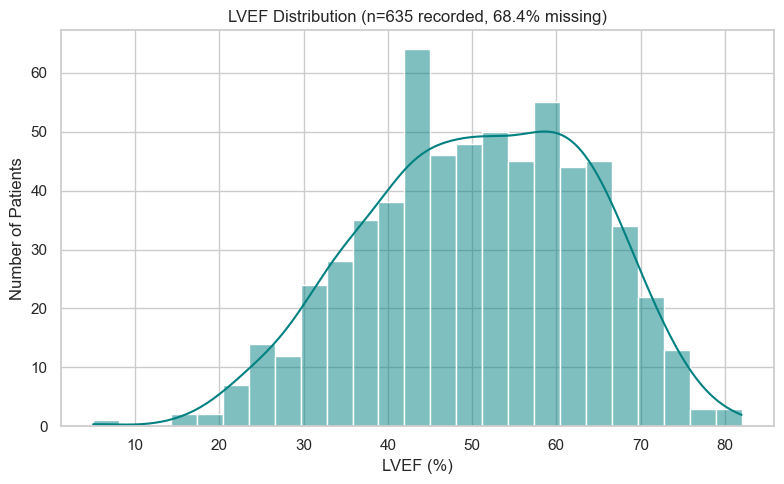

count    635.000000
mean      50.682992
std       13.221701
min        5.000000
25%       41.000000
50%       51.000000
75%       61.000000
max       82.000000
Name: lvef, dtype: float64

Type of heart failure:
type_of_heart_failure
Both     1480
Left      477
Right      51
Name: count, dtype: int64
type_of_heart_failure
Both     73.7
Left     23.8
Right     2.5
Name: proportion, dtype: float64


In [11]:
# Q3: LVEF distribution + missingness, and HF type distribution
lvef_missing_pct = df['lvef'].isna().mean() * 100
lvef_n = df['lvef'].notna().sum()

print(f"LVEF missing: {lvef_missing_pct:.1f}% (n={lvef_n} of {len(df)} have a recorded value)")

plt.figure(figsize=(8, 5))
sns.histplot(df['lvef'].dropna(), bins=25, kde=True, color='teal')
plt.title(f'LVEF Distribution (n={lvef_n} recorded, {lvef_missing_pct:.1f}% missing)')
plt.xlabel('LVEF (%)')
plt.ylabel('Number of Patients')
plt.tight_layout()
plt.show()

print(df['lvef'].describe())

print("\nType of heart failure:")
print(df['type_of_heart_failure'].value_counts(dropna=False))
print(df['type_of_heart_failure'].value_counts(normalize=True, dropna=False).round(3) * 100)

<p style="font-family: Cambria; font-size: 18px;"><b>Q4. What is the comorbidity burden in this cohort, and which comorbidities are most prevalent?</b></p>

**Why:** CCI score and individual comorbidity flags describe chronic disease burden — independent of acute admission severity (Q1).

**What:** `cci_score`, plus flags: cerebrovascular_disease, dementia, chronic_obstructive_pulmonary_disease, connective_tissue_disease, peptic_ulcer_disease, diabetes, moderate_to_severe_chronic_kidney_disease, hemiplegia, leukemia, malignant_lymphoma, solid_tumor, liver_disease, aids, acute_renal_failure.

**How:** Histogram of CCI; ranked bar chart of prevalence (mean of each 0/1 flag).

**Counter-Argument:** Some flags (e.g. `moderate_to_severe_chronic_kidney_disease`, `liver_disease`, `cci_score`) are Float, not Integer, in the cleaned data — a NaN-preserving cast from cleaning, not a data error; worth noting so it isn't mistaken for one.

**What We Expect:** Diabetes and CKD likely dominate, given known HF comorbidity patterns.

**Evidence:** CCI score: mean 1.86, median 2, IQR 1–2 (n=2,003 of 2,008 — 5 patients missing a CCI value). As expected, chronic kidney disease (23.6%) and diabetes (23.2%) are the two most prevalent comorbidities, essentially tied, followed by COPD (11.6%) and cerebrovascular disease (7.5%). Leukemia and malignant lymphoma are effectively absent (0.0%). Note: `acute_renal_failure` (0.3%) was excluded from this comorbidity ranking on review — it's an acute in-hospital event, not a chronic comorbidity like the other 13, so grouping it here would have misrepresented what the question measures.

**Why It Matters:** CKD and diabetes are the two comorbidities Category 4 should prioritize as candidate risk features — they're not just present, they're roughly 2x more prevalent than the next tier (COPD). The near-zero prevalence of leukemia/lymphoma means those two columns are unlikely to be useful predictors anywhere downstream and can probably be dropped from later feature lists rather than carried forward out of habit.

**Follow-Up:** Does comorbidity burden correlate with 6-month readmission?

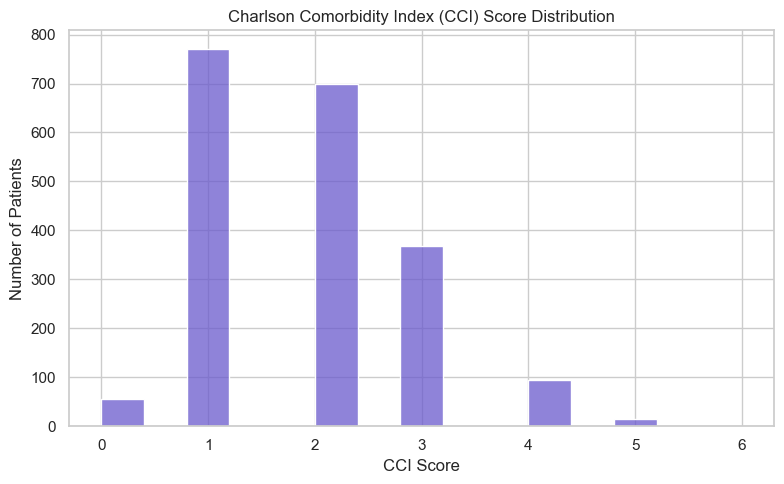

count    2003.000000
mean        1.861707
std         0.961469
min         0.000000
25%         1.000000
50%         2.000000
75%         2.000000
max         6.000000
Name: cci_score, dtype: float64


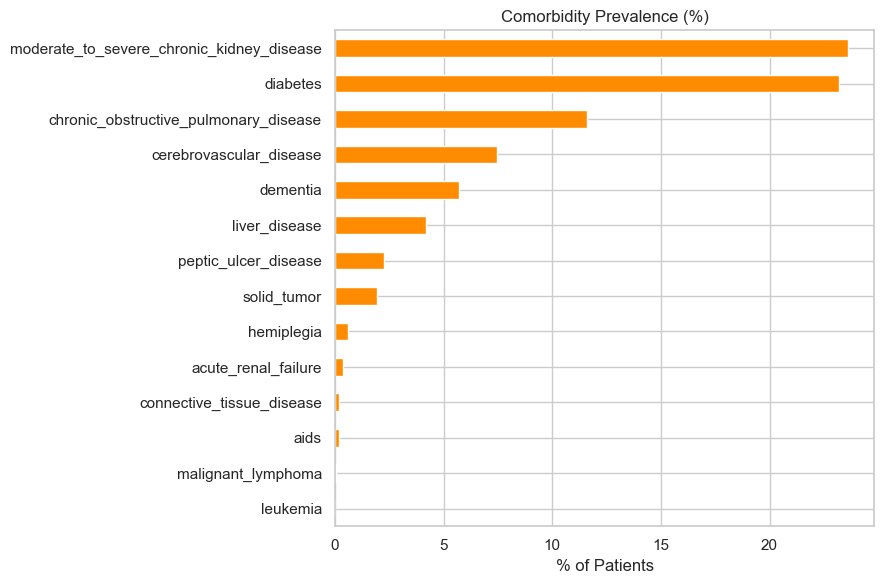

moderate_to_severe_chronic_kidney_disease    23.6
diabetes                                     23.2
chronic_obstructive_pulmonary_disease        11.6
cerebrovascular_disease                       7.5
dementia                                      5.7
liver_disease                                 4.2
peptic_ulcer_disease                          2.2
solid_tumor                                   1.9
hemiplegia                                    0.6
acute_renal_failure                           0.3
connective_tissue_disease                     0.2
aids                                          0.2
malignant_lymphoma                            0.0
leukemia                                      0.0
dtype: float64


In [12]:
# Q4: CCI distribution + top comorbidities
plt.figure(figsize=(8, 5))
sns.histplot(df['cci_score'].dropna(), bins=15, color='slateblue')
plt.title('Charlson Comorbidity Index (CCI) Score Distribution')
plt.xlabel('CCI Score')
plt.ylabel('Number of Patients')
plt.tight_layout()
plt.show()

print(df['cci_score'].describe())

comorbidity_cols = [
    'cerebrovascular_disease', 'dementia', 'chronic_obstructive_pulmonary_disease',
    'connective_tissue_disease', 'peptic_ulcer_disease', 'diabetes',
    'moderate_to_severe_chronic_kidney_disease', 'hemiplegia', 'leukemia',
    'malignant_lymphoma', 'solid_tumor', 'liver_disease', 'aids', 'acute_renal_failure'
]

comorbidity_prevalence = (df[comorbidity_cols].mean() * 100).sort_values(ascending=False)

plt.figure(figsize=(9, 6))
comorbidity_prevalence.plot(kind='barh', color='darkorange')
plt.title('Comorbidity Prevalence (%)')
plt.xlabel('% of Patients')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(comorbidity_prevalence.round(1))

<p style="font-family: Cambria; font-size: 18px;"><b>Q5. What are the cohort's baseline death and readmission rates at 28 days, 3 months, and 6 months?</b></p>

**Why:** This is the anchor every Category 3/4 subgroup finding gets compared against — a subgroup rate means nothing without the overall rate stated first.

**What:** `death_within_28_days`, `re_admission_within_28_days`, `death_within_3_months`, `re_admission_within_3_months`, `death_within_6_months`, `re_admission_within_6_months`, `outcome_during_hospitalization`.

**How:** One summary table of rates — a table, not a chart, since the point is precise, quotable numbers.

**Counter-Argument:** Six near-identical columns could look like padding — they're one construct (time-windowed views of the same two outcomes), not six separate questions.

**What We Expect:** Rates should rise monotonically from 28 days → 6 months (more time = more events).

**Evidence:** Both death and readmission rates rise monotonically with time window, as expected: death 1.8% (28d) → 2.1% (3mo) → 2.8% (6mo); readmission 7.0% (28d) → 24.8% (3mo) → 38.5% (6mo). In-hospital outcome: 94.1% discharged alive, 5.3% (n=107) discharged against medical order, 0.5% (n=11) died in-hospital. Notably, in-hospital mortality (0.5%) is far lower than 28-day mortality (1.8%) — most 28-day deaths occur post-discharge, not during the admission itself.

**Why It Matters:** Readmission, not death, is this cohort's dominant risk — by 6 months, over 1 in 3 patients are back in the hospital, versus under 3% who have died. This should steer where the team spends its Category 3/4 effort: readmission-focused questions have far more signal (773 events) to work with than mortality-focused ones (57 events at 6 months) will ever have. Separately, the 107 patients discharged against medical order is a large enough, well-defined group to support Dhivya's reserve question on outcomes for that specific subgroup — worth promoting that into the active Category 3 list rather than leaving it as a reserve idea.

**Follow-Up:** Which subgroups deviate most from these baseline rates?



In [14]:
# Q5: Baseline outcome rates
outcome_cols = [
    'death_within_28_days', 're_admission_within_28_days',
    'death_within_3_months', 're_admission_within_3_months',
    'death_within_6_months', 're_admission_within_6_months'
]

outcome_rates = (df[outcome_cols].mean() * 100).round(1)
outcome_summary = pd.DataFrame({
    'Rate (%)': outcome_rates,
    'Count': df[outcome_cols].sum().astype(int)
})
print(outcome_summary)

print("\nIn-hospital outcome:")
print(df['outcome_during_hospitalization'].value_counts())
print(df['outcome_during_hospitalization'].value_counts(normalize=True).round(3) * 100)

                              Rate (%)  Count
death_within_28_days               1.8     37
re_admission_within_28_days        7.0    140
death_within_3_months              2.1     42
re_admission_within_3_months      24.8    498
death_within_6_months              2.8     57
re_admission_within_6_months      38.5    773

In-hospital outcome:
outcome_during_hospitalization
Alive                      1890
Discharge Against Order     107
Dead                         11
Name: count, dtype: int64
outcome_during_hospitalization
Alive                      94.1
Discharge Against Order     5.3
Dead                        0.5
Name: proportion, dtype: float64


In [ ]:
# Step 2: Show one bar chart per clinical assessment, with both counts and percentages.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (name, summary) in zip(axes, severity_tables.items()):
    bars = ax.bar(summary["Grade"].astype(str), summary["Patients"], color="#3274a1")
    ax.set(title=f"Patients by {name}", xlabel=name, ylabel="Number of patients")
    ax.set_ylim(0, max(1, summary["Patients"].max()) * 1.16)
    for bar, count, percent in zip(bars, summary["Patients"], summary["Percent of all patients"]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                f"{count:,} ({percent:.1f}%)", ha="center", va="bottom", fontsize=9)

fig.suptitle("Admission severity: two different clinical assessments", fontsize=14)
plt.tight_layout()
plt.show()

# State a finding using the real counts after the dataset has been loaded.
for name, summary in severity_tables.items():
    largest = summary.loc[summary["Patients"].idxmax()]
    print(f"Most common {name}: {int(largest['Grade'])} — "
          f"{int(largest['Patients']):,} patients ({largest['Percent of all patients']:.1f}% of all patients).")


### What Question 1 tells us

The tables and charts establish how common each recorded severity grade is in the full patient group. Use the displayed percentages and missing counts when describing the result. A large count for one grade tells us that grade was common *in this dataset*; it does not explain what caused the patient's condition.


## Question 2 — How do NYHA classes and Killip grades overlap in the same patients?

**Why this question?** Question 1 counts each grade separately. A table of patients who have *both* recorded scores shows which combinations occurred together, including whether patients within one NYHA class received several different Killip grades. This helps the team decide what comparisons to explore later.

**How we answer it:** Keep only patients with both recorded grades. Cross-tabulate their NYHA class and Killip grade, then divide each NYHA row by its own total. A heatmap displays the counts and within-class percentages. We also report how many patients were left out for missing grades.

**Interpretation limit:** NYHA and Killip assess different aspects of illness. Their numerical grade labels do not mean the same thing, so a diagonal on the chart is **not** an agreement rate. Formal correlation and outcome comparisons belong in the separate prescriptive notebook.


In [ ]:
# Step 1: Use the same patient-level table as Question 1.
nyha_column = "nyha_cardiac_function_classification"
killip_column = "killip_grade"
severity_pairs = df[[nyha_column, killip_column]].dropna().copy()

# Count every observed NYHA/Killip combination; keep the expected grade order.
pair_counts = pd.crosstab(
    severity_pairs[nyha_column].astype(int),
    severity_pairs[killip_column].astype(int),
).reindex(index=[2, 3, 4], columns=[1, 2, 3, 4], fill_value=0)
pair_counts.index.name = "NYHA class"
pair_counts.columns.name = "Killip grade"

# Each percentage is within one NYHA class (each nonempty row sums to 100%).
row_totals = pair_counts.sum(axis=1)
pair_percent = pair_counts.div(row_totals.replace(0, np.nan), axis=0).mul(100).round(1)

print(f"Patients with both grades: {len(severity_pairs):,} of {len(df):,}")
print(f"Patients missing one or both grades: {len(df) - len(severity_pairs):,}")
print("\nNumber of patients in each combination:")
display(pair_counts)
print("Percent within each NYHA class (rows):")
display(pair_percent)


In [ ]:
# Step 2: Label each heatmap cell with both the patient count and the row percentage.
labels = np.array([
    [f"{pair_counts.loc[nyha, killip]:,}\n{pair_percent.loc[nyha, killip]:.1f}%"
     if row_totals.loc[nyha] else "No patients"
     for killip in pair_counts.columns]
    for nyha in pair_counts.index
])

plt.figure(figsize=(10, 5))
sns.heatmap(
    pair_percent.fillna(0), annot=labels, fmt="", cmap="Blues", vmin=0, vmax=100,
    cbar_kws={"label": "Percent within NYHA class"}, linewidths=0.5,
)
plt.title("How NYHA classes and Killip grades overlap")
plt.xlabel("Killip grade")
plt.ylabel("NYHA class")
plt.tight_layout()
plt.show()

# Give the reader a factual result without claiming that matching numbers mean agreement.
largest_pair = pair_counts.stack().idxmax()
largest_count = int(pair_counts.loc[largest_pair])
print(f"Most frequent combination: NYHA {largest_pair[0]} and Killip {largest_pair[1]} "
      f"({largest_count:,} patients, {largest_count / len(severity_pairs):.1%} of patients with both grades).")


### What Question 2 tells us

Read *across a row* to see how Killip grades are distributed among patients in one NYHA class. The percentage denominator changes from row to row and is printed in the table above. The chart describes overlap in this patient group; it cannot tell us that one score causes the other or that the two assessments measure the same condition.
